# Evaluación cuantitativa de máscaras sobre cubos DESI

**Proyecto:** Inferencia de propiedades físicas de galaxias a partir de imágenes multibanda
**Datos:** 10 cubos DESI Legacy DR10 (g, r, z; 800×800 px; 0.262″/px) seleccionados por el Dr. Hernández Toledo, y el catálogo maestro `inferencia.fits` del Dr. Vázquez Mata.
**Versión del dataset:** `dataset/v0.3-desi10-maskeval`

## Motivación

La etapa de segmentación busca aislar la galaxia objetivo conservando su luz detectable y reduciendo la contaminación de vecinos. Hasta ahora la calidad de una máscara se juzgaba viendo la imagen. Este cuaderno propone **cuatro métricas objetivas** para calificar cualquier máscara, las aplica a cinco máscaras de referencia sobre los 10 cubos, y con ello responde con números a dos decisiones de diseño:

1. **¿Sobre qué banda (o combinación) conviene segmentar?**
2. **¿Cómo verificamos que una máscara capturó toda la luz de la galaxia, y con qué criterio fijamos sus parámetros para galaxias distintas de M51?**

El objetivo no es proponer una máscara final. Es construir el **instrumento de medición** con el que compararemos el método de contornos activos (Lupton + `morphological_geodesic_active_contour`) contra alternativas, y con el que fijaremos sus parámetros de forma reproducible.


In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
EVAL = ROOT / "Datos" / "interim" / "mask_eval"
FIG = EVAL / "figures"

metrics = pd.read_csv(EVAL / "metrics.csv")
summary = json.load(open(EVAL / "summary.json"))
pd.set_option("display.precision", 3)
print(f"{summary['n_galaxies']} galaxias × {metrics['mask'].nunique()} máscaras = {len(metrics)} evaluaciones")

10 galaxias × 5 máscaras = 50 evaluaciones


## 1. Cómo está construido el pipeline de datos (y por qué)

Vamos a preprocesar miles de imágenes varias veces (distintos recortes, normalizaciones, máscaras, mapas de estructura). Para poder iterar rápido sin perder la trazabilidad de qué datos produjeron qué resultado, el repositorio usa **DVC (Data Version Control)** encima de git:

```
Catálogos + cubos FITS (entrada)
   └─ ingest      → manifiesto + imágenes crudas
        └─ cutout     → recorte centrado         (params: cutout.*)
             ├─ normalize → intensidades [0,1]     (params: normalize.*)
             └─ segment   → máscaras               (params: segment.*)
                  └─ structure → mapas CAS          (params: structure.*)
                       └─ split → cubos Zarr train/val/test
   └─ mask_eval  → métricas + figuras de este cuaderno   (params: mask_eval.*)
```

- **`dvc.yaml`** declara cada etapa con su código, sus entradas, sus parámetros y sus salidas.
- **`params.yaml`** concentra todos los valores ajustables (radio de recorte, método de normalización, umbral de la máscara, semilla de las particiones…).
- **`dvc.lock`** guarda el hash MD5 de cada entrada, parámetro y salida. Git versiona ese archivo pequeño; los bytes de las imágenes viven en un almacén de contenido direccionable por hash, fuera de git.

Consecuencias prácticas:

| Necesidad | Cómo se resuelve |
|---|---|
| Cambiar un parámetro y regenerar | `dvc repro` reejecuta **solo** las etapas afectadas y las que dependen de ellas |
| Nombrar una versión del dataset | un tag de git: `dataset/v0.3-desi10-maskeval` |
| Recuperar exactamente esa versión meses después | `git checkout <tag> && dvc pull` |
| Saber qué cambió entre dos versiones sin descargar nada | `git diff` de `params.yaml` y de los `*_summary.json` |
| No duplicar almacenamiento entre versiones | dos versiones que comparten el 90 % de las imágenes almacenan esas imágenes una sola vez |

Todo lo que se muestra abajo (tabla, figuras) fue producido por la etapa `mask_eval` con los parámetros siguientes, y se regenera con un solo comando.

In [2]:
import yaml
print(yaml.safe_dump({"mask_eval": summary["params"]}, sort_keys=False))

mask_eval:
  catalog: Datos/inferencia.fits
  cubes: Datos/DESI
  iso_sb: 25.0
  ref_factor: 2.0
  threshold:
    grow_px: 2
    nsigma: 2.0
    smooth_px: 2.0



## 2. Las diez galaxias

Cada cubo se cruza con `inferencia.fits` por `MANGAID`. Del catálogo usamos `PETRO_TH90`, el radio (en segundos de arco) que contiene el 90 % de la luz Petrosian medida por SDSS. Es una **medida independiente del tamaño de cada galaxia**, y es lo que permite calificar una máscara en lugar de solo mirarla.

Círculo amarillo = `PETRO_TH90`. Contorno blanco = máscara isofotal a 25 mag/arcsec² en r (se explica abajo).

,name,T_11,LogMassNSA,nsa_sersic_n,PETRO_TH90,C,A,S
MANGAID,,,,,,,,
1-115357,manga-7978-12703,5,9.90,0.90,20.19,2.82,0.08,-0.31
1-148527,manga-8994-6103,-2,10.09,2.23,7.20,2.98,0.07,0.17
1-210759,manga-12674-6101,-2,10.47,1.37,13.84,3.98,0.24,0.49
1-317938,manga-9092-9102,3,10.15,1.30,15.48,3.09,0.11,0.35
1-338796,manga-8137-12703,5,10.51,1.45,18.11,2.88,0.18,0.20
1-415975,manga-12624-12704,7,9.12,1.47,10.47,3.02,0.20,0.16
1-456530,manga-8935-6101,3,8.89,1.67,12.14,3.22,0.08,-0.30
1-457140,manga-9863-12701,6,8.59,1.48,12.20,2.76,0.12,0.07
1-491047,manga-8450-6101,1,10.40,4.96,18.28,3.72,0.06,0.13


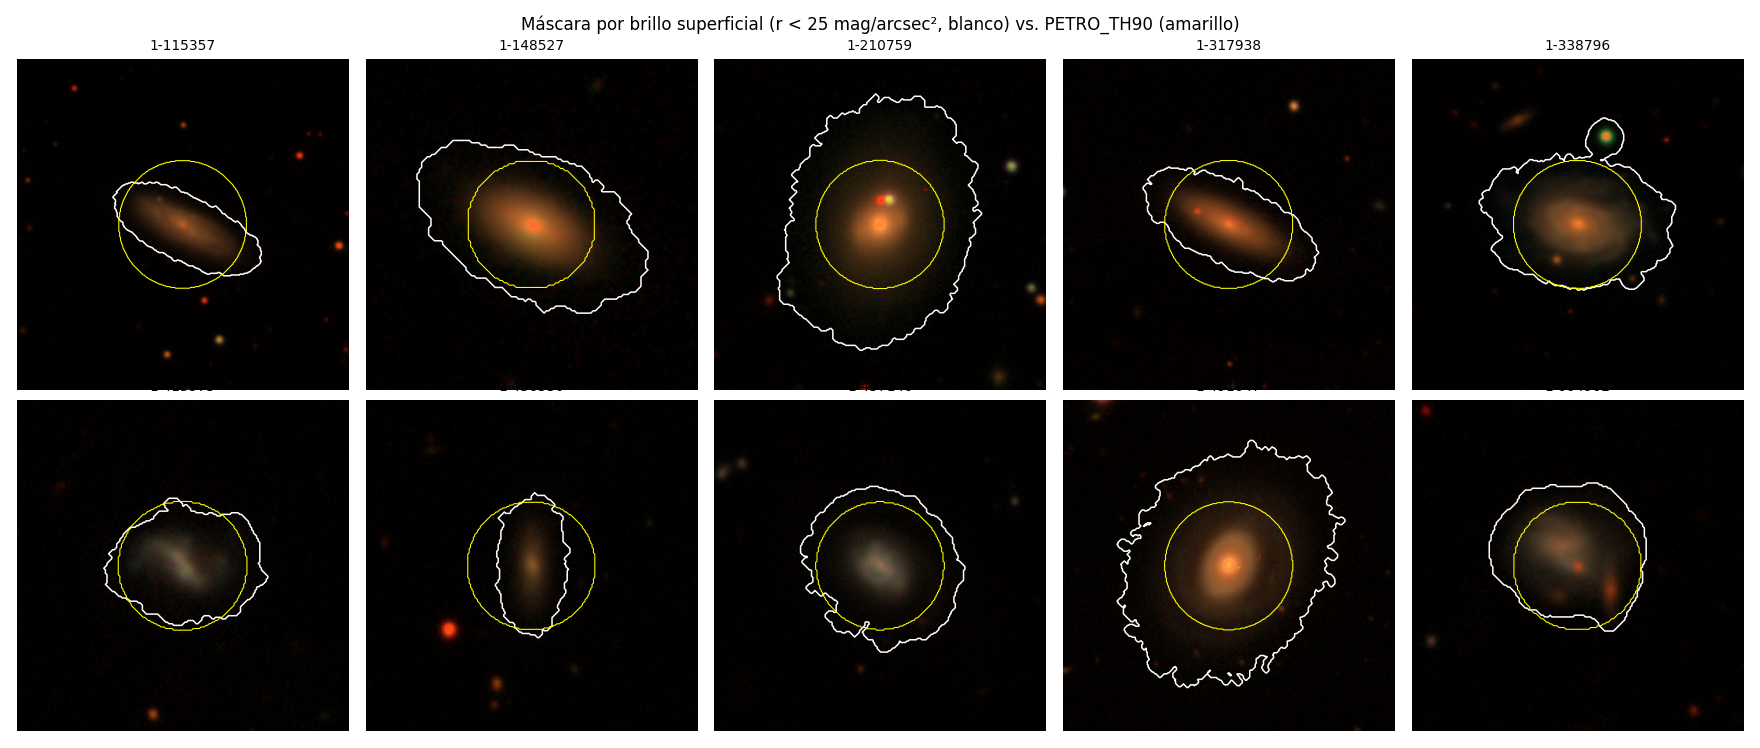

In [3]:
from astropy.table import Table

cat = Table.read(ROOT / "Datos" / "inferencia.fits").to_pandas()
cat["MANGAID"] = cat["MANGAID"].str.decode("utf-8").str.strip()
cat["name"] = cat["name"].str.decode("utf-8").str.strip()
ids = sorted(metrics["mangaid"].unique())
muestra = cat.set_index("MANGAID").loc[ids, ["name", "T_11", "LogMassNSA", "nsa_sersic_n", "PETRO_TH90", "C", "A", "S"]]
display(muestra.round(2))
display(Image(filename=str(FIG / "grid.png"), width=1100))

## 3. Máscaras de referencia y métricas

### Cinco máscaras sencillas para tener un patrón de comparación

| Máscara | Regla |
|---|---|
| `thr_g`, `thr_r`, `thr_z` | Suavizado gaussiano (σ = 2 px); píxeles > 2σ del ruido de cielo medido en el borde; componente conexa que toca el centro; relleno de huecos; dilatación de 2 px. Misma receta, una banda a la vez. |
| `thr_grz` | La misma receta sobre la suma g + r + z. |
| `sb_r` | Píxeles con brillo superficial en r **más brillante que 25 mag/arcsec²** (isofota estándar en morfología de galaxias); componente central; dilatación de 2 px. No tiene umbral ajustable. |

Ninguna de estas es la propuesta final. Son el metro con el que mediremos el método de contornos activos cuando esté integrado en el pipeline.

### Cuatro métricas, por máscara y por galaxia

1. **Fracción de luz capturada.** Flujo dentro de la máscara ÷ flujo dentro de un círculo de radio 2·`PETRO_TH90` (que por construcción contiene prácticamente toda la luz de la galaxia). 1.00 = la máscara capturó todo. Se calcula por banda.
2. **Contaminación.** Se detectan fuentes con `photutils`; toda fuente que no sea la galaxia central es un vecino. Contaminación = fracción del flujo *dentro de la máscara* que proviene de vecinos. 0 = máscara limpia.
3. **Razón de áreas.** Área de la máscara ÷ área del círculo `PETRO_TH90`. Valores altos (> 3) indican que la máscara está creciendo sobre ruido de cielo, no sobre la galaxia.
4. **Radio isofotal por banda** (independiente de la máscara). Radio al que el perfil azimutal cae a 25 mag/arcsec² en g, en r y en z. Cuantifica cuánto cambia la extensión aparente con el filtro.

Detalle importante: antes de calcular 1 y 4, los píxeles de vecinos se ponen a cero (contornos naranja punteados en las figuras). Sin esto, una estrella brillante dentro del círculo de referencia distorsiona el denominador; en la primera corrida una galaxia reportaba "1600 % de luz capturada" por esta causa.

### Ejemplo: 1-456530, una galaxia con una estrella vecina

Panel izquierdo: compuesto RGB Lupton. Centro: máscaras (verde/rojo/morado/blanco = umbral en g/r/z/grz; cian = isofota 25 en r; amarillo = R90 y 2·R90; naranja = vecinos excluidos). Derecha: curva de crecimiento por banda; la línea horizontal marca el 90 % y las verticales el radio equivalente de cada máscara.

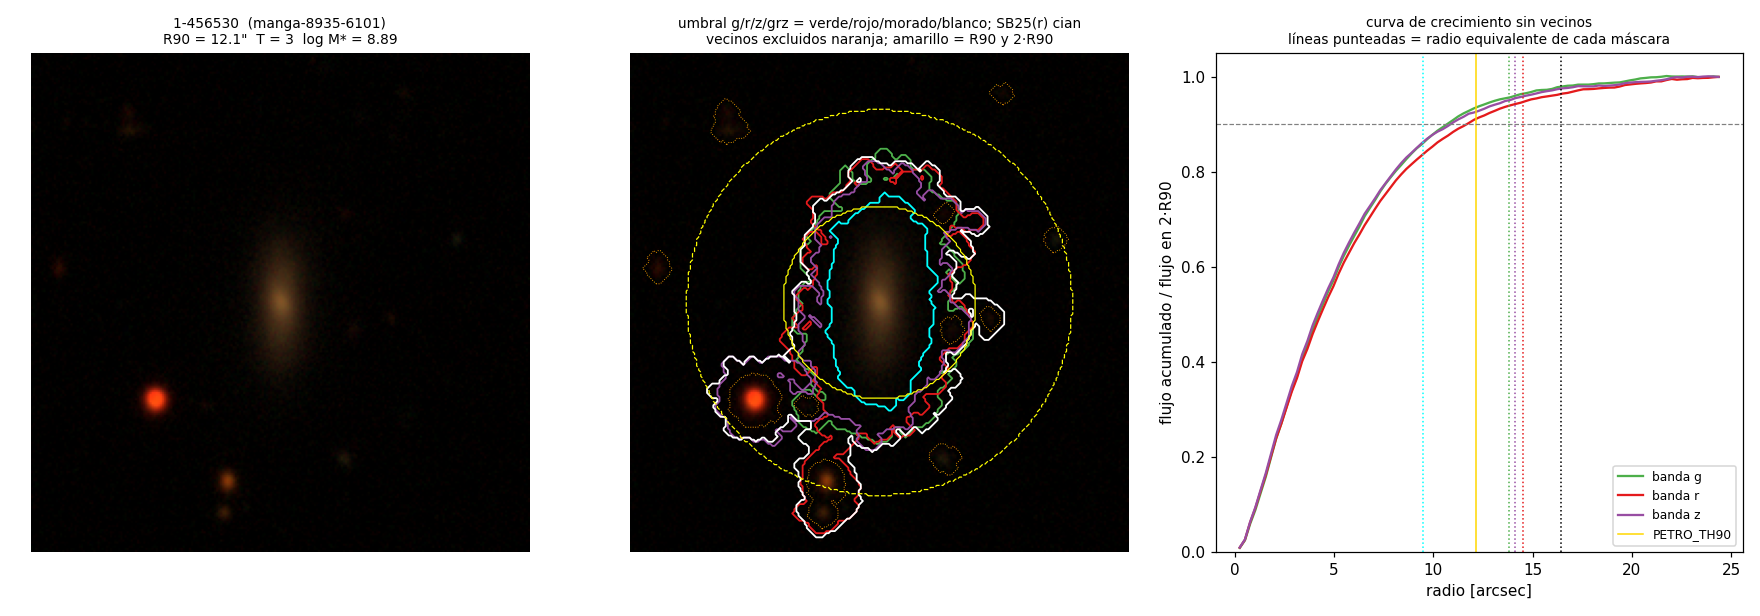

,light_frac_g,light_frac_r,light_frac_z,contam_r,area_ratio,r_mask_arcsec
mask,,,,,,
thr_g,0.982,0.949,0.966,0.001,1.292,13.800
thr_r,0.977,0.969,0.978,0.047,1.430,14.518
thr_z,0.961,0.943,0.985,0.233,1.350,14.104
thr_grz,0.987,0.977,1.013,0.252,1.835,16.447
sb_r,0.894,0.873,0.895,0.001,0.608,9.463


In [4]:
display(Image(filename=str(FIG / "1-456530.png"), width=1300))
metrics[metrics["mangaid"] == "1-456530"].set_index("mask")[
    ["light_frac_g", "light_frac_r", "light_frac_z", "contam_r", "area_ratio", "r_mask_arcsec"]
]

Se ve el efecto directamente: las máscaras por umbral en g y en g+r+z absorben la estrella (contaminación alta), mientras que la isofota y el umbral en r la dejan fuera.

## 4. Resultados sobre las 10 galaxias

In [5]:
cols = ["light_frac_g", "light_frac_r", "light_frac_z", "contam_r", "area_ratio", "r_mask_arcsec"]
tabla = metrics.groupby("mask")[cols].agg(["mean", "std"]).round(3)
tabla = tabla.reindex(["thr_r", "thr_z", "thr_g", "thr_grz", "sb_r"])
tabla

light_frac_g        light_frac_r        light_frac_z        contam_r  \
                mean    std         mean    std         mean    std     mean   
mask                                                                           
thr_r          0.997  0.012        0.999  0.014        0.999  0.011    0.020   
thr_z          0.983  0.017        0.982  0.019        0.998  0.011    0.026   
thr_g          1.022  0.061        1.019  0.075        1.028  0.094    0.105   
thr_grz        1.030  0.093        1.039  0.124        1.061  0.163    0.130   
sb_r           0.958  0.028        0.956  0.036        0.965  0.036    0.012   

               area_ratio        r_mask_arcsec          
           std       mean    std          mean     std  
mask                                                    
thr_r    0.032      2.839  1.425        22.345   9.291  
thr_z    0.073      2.204  1.071        19.734   7.951  
thr_g    0.279      3.693  2.817        24.325   9.732  
thr_grz  0.280      4.273  4.273        25.295  10.772  
sb_r     0.030      1.581  0.861        16.654   7.267

In [6]:
iso = metrics[metrics["mask"] == "sb_r"].set_index("mangaid")[
    ["petro_th90_arcsec", "r_iso_g_arcsec", "r_iso_r_arcsec", "r_iso_z_arcsec"]
].copy()
iso["g / r"] = iso["r_iso_g_arcsec"] / iso["r_iso_r_arcsec"]
iso["z / r"] = iso["r_iso_z_arcsec"] / iso["r_iso_r_arcsec"]
iso["r_iso(r) / R90"] = iso["r_iso_r_arcsec"] / iso["petro_th90_arcsec"]
display(iso.round(2))
print("Promedios:", iso[["g / r", "z / r", "r_iso(r) / R90"]].mean().round(2).to_dict())

,petro_th90_arcsec,r_iso_g_arcsec,r_iso_r_arcsec,r_iso_z_arcsec,g / r,z / r,r_iso(r) / R90
mangaid,,,,,,,
1-115357,20.19,15.72,18.34,19.91,0.86,1.09,0.91
1-148527,7.20,7.86,9.43,9.96,0.83,1.06,1.31
1-210759,13.84,18.86,23.06,22.01,0.82,0.95,1.67
1-317938,15.48,13.62,16.77,18.86,0.81,1.12,1.08
1-338796,18.11,20.44,22.01,20.44,0.93,0.93,1.22
1-415975,10.47,9.43,9.96,10.48,0.95,1.05,0.95
1-456530,12.14,7.34,9.43,9.96,0.78,1.06,0.78
1-457140,12.20,9.96,14.15,15.20,0.70,1.07,1.16
1-491047,18.28,25.15,29.34,34.58,0.86,1.18,1.61


Promedios: {'g / r': 0.84, 'z / r': 1.05, 'r_iso(r) / R90': 1.19}


### Lectura de los resultados

**Sobre qué banda segmentar.** El umbral en **r** captura toda la luz (0.999 ± 0.014) con la menor dispersión entre galaxias y 2 % de contaminación. Agregar la banda g, o sumar las tres, **empeora** el resultado: g es la banda más ruidosa y ese ruido conecta la máscara con vecinos (10–13 % de contaminación, con varianza enorme entre galaxias). Combinar bandas antes de segmentar no ayuda; segmentar sobre una sola imagen bien comportada sí.

**Extensión por banda.** A la isofota de 25 mag/arcsec², la galaxia en g es en promedio 16 % más pequeña que en r, y en z 5 % más grande. Además, el radio isofotal en r es ≈ 1.2 × `PETRO_TH90`: el valor del catálogo predice bien el tamaño del recorte necesario, como sugirió el Dr. Vázquez.

**Cómo medir que la máscara capturó la luz, y cómo fijar parámetros.** La fracción de luz respecto a 2·R90 es una métrica directa y reproducible. La máscara isofotal `sb_r` cede ≈ 4 % de la luz exterior más tenue, pero es la más limpia (1 % de contaminación), la más compacta (1.6 × área R90) y **la más estable entre galaxias** (su área relativa a la de r varía solo 0.04). No requiere ajuste por galaxia: el nivel 25 mag/arcsec² es una convención física, no un parámetro afinado sobre M51.

**Caso límite: galaxias brillantes y extendidas.** En 1-491047 (log M* = 10.4) las máscaras por umbral llegan a > 40″ cuando la luz de la galaxia termina cerca de 25″: el umbral de ruido captura el halo tenue más ruido de cielo. La isofota se detiene donde debe.

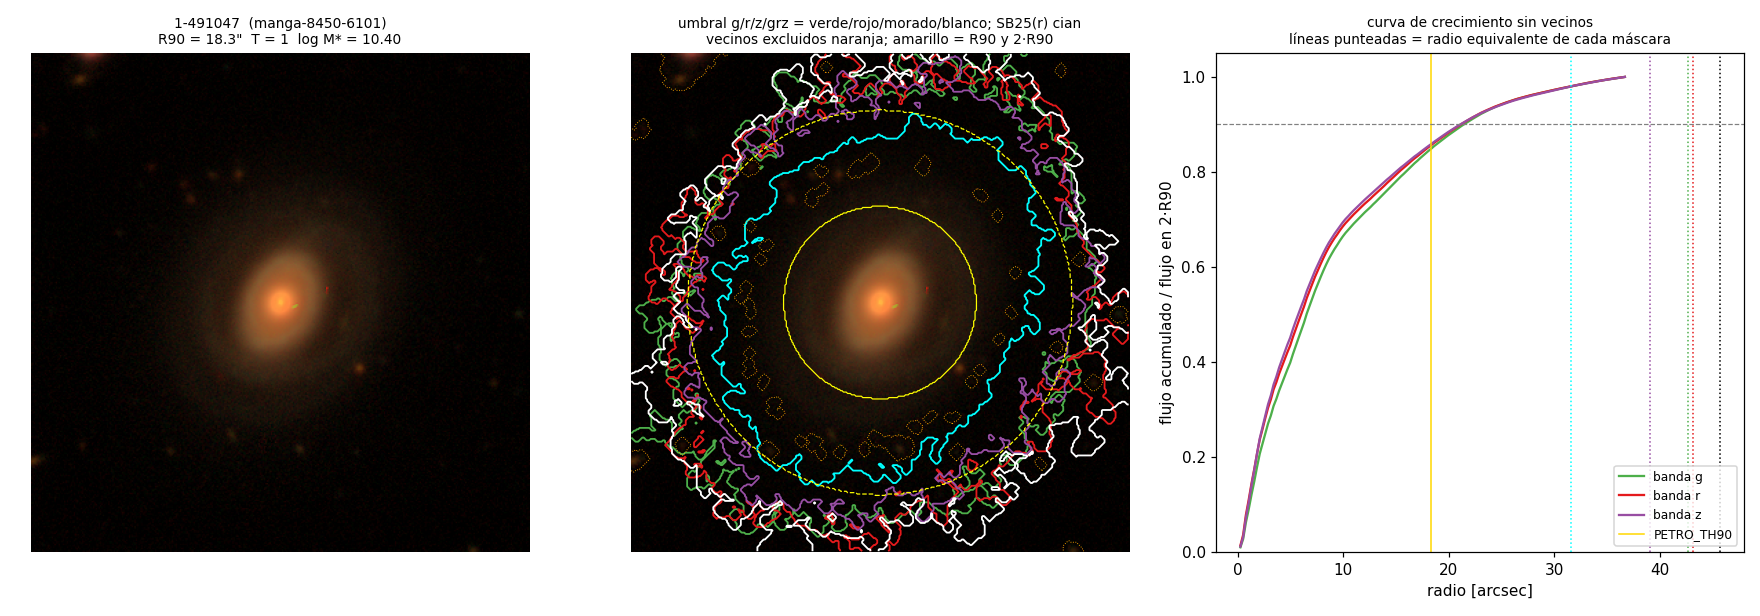

In [7]:
display(Image(filename=str(FIG / "1-491047.png"), width=1300))

## 5. Alcance y siguientes pasos

**Lo que no se afirma.** Diez galaxias son un piloto, no una estadística. El umbral (2σ) y el nivel isofotal (25) se fijaron una vez, no se optimizaron; otros valores mueven los números aunque probablemente no el orden. Las cinco máscaras son deliberadamente simples: son la regla de medir, no la propuesta.

**Siguientes pasos.**

1. Integrar el método de contornos activos (Lupton + geodésico) como sexta máscara candidata. El arnés no cambia; obtenemos la misma tabla para él.
2. Con eso, la elección de umbral, inflación y radio de estrellas deja de ser visual: se convierte en maximizar la fracción de luz sujeto a una cota de contaminación, sobre una muestra de validación tomada del catálogo.
3. Extender la corrida a una muestra mayor (el script de descarga ya está parametrizado con `PETRO_TH90` para el zoom).
4. Comparar C, A, S calculados sobre nuestras máscaras contra los valores del catálogo como validación adicional de toda la cadena.

**Reproducibilidad.** Todo lo anterior se regenera con:

```bash
git checkout dataset/v0.3-desi10-maskeval
dvc pull
dvc repro mask_eval
```

Código: `src/data/desi.py` (lectura de cubos y catálogo), `src/data/mask_eval.py` (máscaras y métricas), `src/data/evaluate_masks.py` (orquestación y figuras). Parámetros en `params.yaml`, sección `mask_eval`.